In [1]:
print("Hello World")

Hello World


In [2]:
#CODE TO fetch the data

In [3]:
import os
import tarfile
from six.moves import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml/master/"
HOUSING_PATH = "datasets/housing"
HOUSING_URL = DOWNLOAD_ROOT + HOUSING_PATH + "/housing.tgz"

def fetch_housing_data(housing_url = HOUSING_URL , housing_path = HOUSING_PATH):
    # Fixed typo: makedris -> makedirs
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
        
    tgz_path = os.path.join(housing_path , "housing.tgz")
    urllib.request.urlretrieve(housing_url , tgz_path)
    
    housing_tgz = tarfile.open(tgz_path)
    # Fixed typo: extractcall -> extractall
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()

# Run the function to extract the data
fetch_housing_data()

In [4]:
import pandas as pd

def load_housing_data(housing_path = HOUSING_PATH):
    csv_path  = os.path.join(housing_path , "housing.csv")
    return pd.read_csv(csv_path)

In [5]:
# IN THIS WE ASSIGN THE DATA TO A VARIABLE 

In [6]:
housing = load_housing_data()


In [7]:
# HERE WHAT WE ARE DOING IS THAT SINCE THE ATTRIBUTE "OCEAN PROXIMITY" IS A CLASSIFICATION ATTRIBUTE SO WE RUN AND CHECK HOW MANY IN EACH OF THE LEVEL


In [8]:
# VALUE_COUNTS() IS A FUNCTION IN PANDAS WHICH TELLS TO HOW MANY DATA SET POINTS SHARE THE SAME ATTRIBUTE LEVEL

In [9]:
#QUICK LOOK AT THE DATA

In [10]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [11]:
# INFO - QUICK DESCRIPTION OF THE DATA , total number of rows, columns and each attributr's type and number of non-null value

In [12]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [13]:
# DESCRIBE() METHOD SHOWS A SUMMARY(mean , mode , min , max , std. deviation , percentileth ,count) OF THE NUMERICAL ATTRIBUTES

In [14]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [15]:
#HISTOGRAM SHOWS NUMBER OF INSTANCES ON THE VERTICAL END AND THE RANGE OF THE ATTRIBUTE ON THE HORIZONTAL END 

In [16]:
#use hist() for the histograms for all of them 

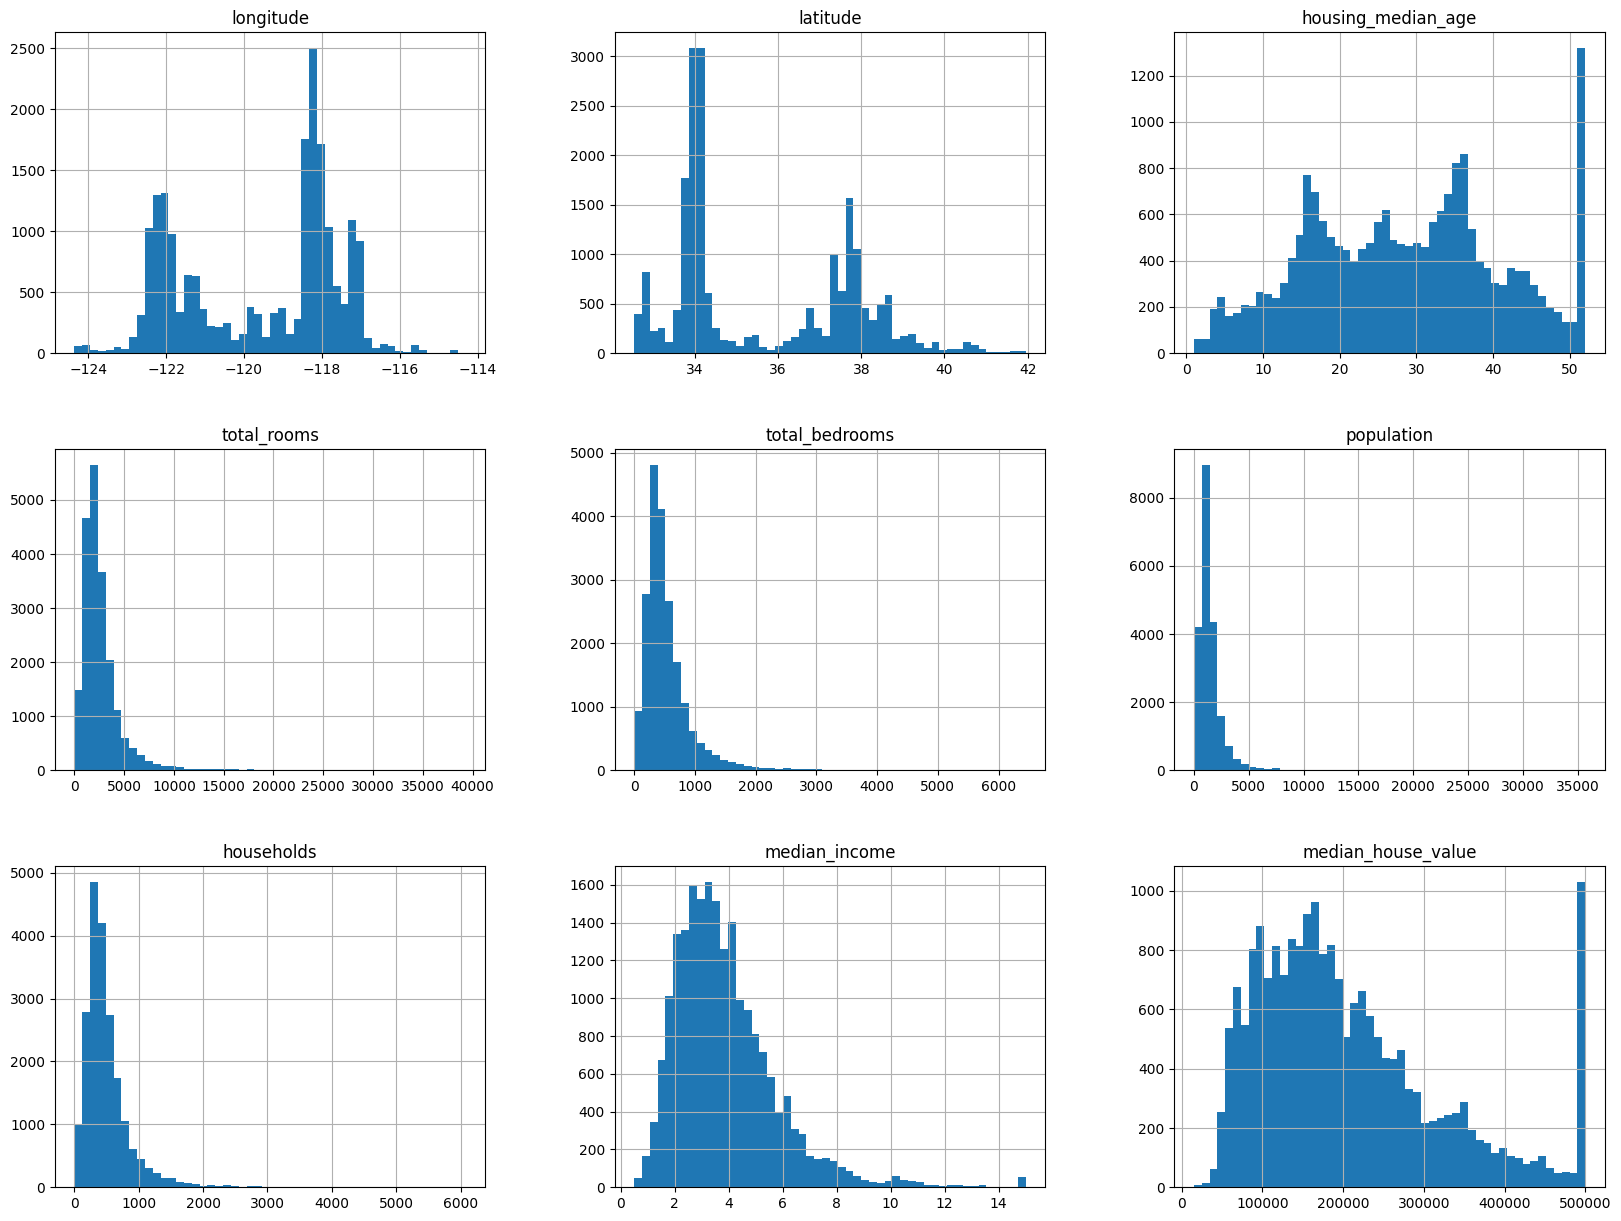

In [17]:
import matplotlib.pyplot as plt
housing.hist(bins=50 , figsize=(20,15))
plt.show()

In [18]:
#CREATE A TEST SET

In [19]:
import numpy as np
def split_train_set(data,test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_data_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_data_size]
    train_indices = shuffled_indices[test_data_size:]
    return data.iloc[train_indices] ,data.iloc[test_indices]

In [20]:
#run the function

In [21]:
#run the function
train_set , test_set = split_train_set(housing,0.2)
print(len(train_set))
print(len(test_set))

16512
4128


In [22]:
#HASHING HERE FOR A COHERENT TEST AND TRAINING SET

In [23]:
#THE FUNCTION THAT DOES THE HASHING PART..

In [24]:
from zlib import crc32
def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32

In [25]:
#THE ACTUAL FUCTION THAT MAKES TEST AND TRAIN SET

In [26]:
def split_train_test_data(data, test_ratio , id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [27]:
#turns out our data doesn't have an id column

In [28]:
# INBUILT FUNCTION FOR TEST , TRAIN SET


In [29]:
from sklearn.model_selection import train_test_split
train_set,test_set= train_test_split(housing , test_size = 0.2 , random_state = 42)



In [30]:
# use the row index as the ID

In [31]:
#DISCOVER AND VISUALIZE THE DATA TO GAIN INSIGHTS

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

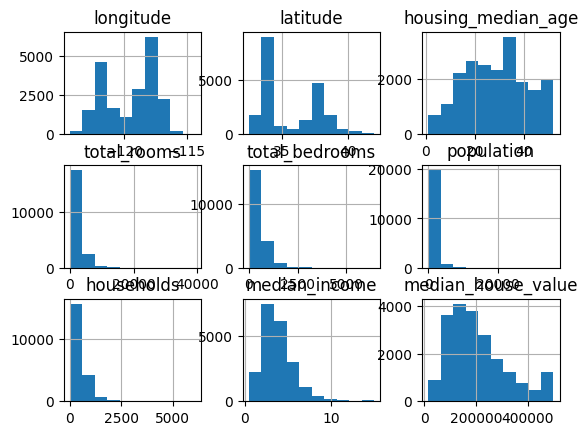

In [32]:
housing.hist()




In [33]:
housing["income_cat"] = pd.cut(housing["median_income"],
bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
labels=[1, 2, 3, 4, 5])

<Axes: >

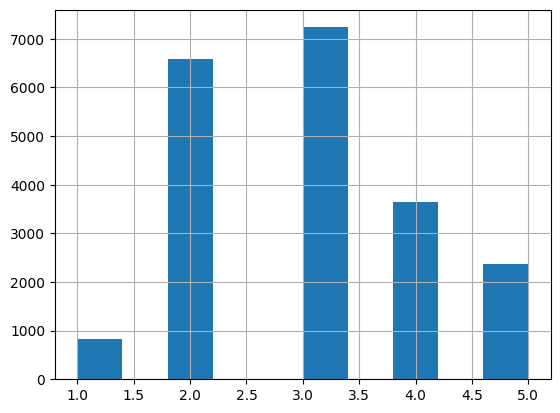

In [34]:
housing["income_cat"].hist()

In [35]:
#NOW WE ARE READY TO DO STARTIFIED SPLITING OF THE DATA SET  FOR TEST AND TRAIN SET

In [36]:
from sklearn.model_selection import StratifiedShuffleSplit

In [37]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [38]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [39]:
strat_test_set["income_cat"].value_counts()

income_cat
3    1447
2    1316
4     728
5     472
1     165
Name: count, dtype: int64

In [40]:
for set_ in (strat_train_set ,strat_test_set):
    set_.drop("income_cat",axis = 1 ,inplace = True)

In [41]:
#NOW WE MANUPLUATE DATA AND YK TRY THINGS


In [42]:
#CREATE A COPY

In [43]:
housing = strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

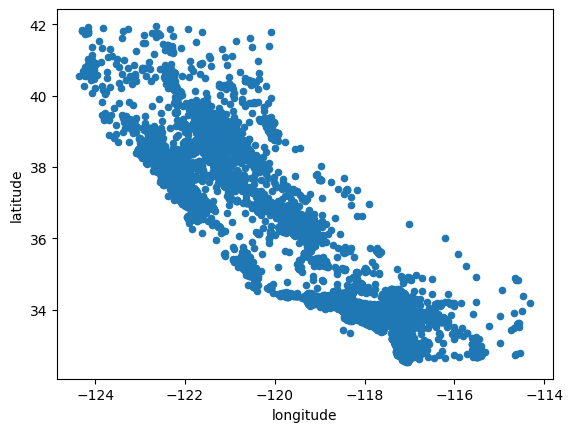

In [44]:
housing.plot(kind="scatter", x="longitude", y="latitude")

In [45]:
#ENHANCE THE IMAGE...
#SET ALPHA = 0.1

<Axes: xlabel='longitude', ylabel='latitude'>

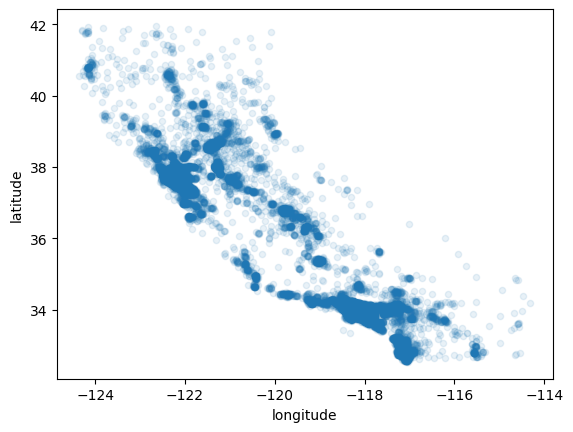

In [46]:
housing.plot(kind ="scatter", x="longitude",y="latitude",alpha=0.1)

In [47]:
#POPULATION VS. PRICE (JET MODELING)

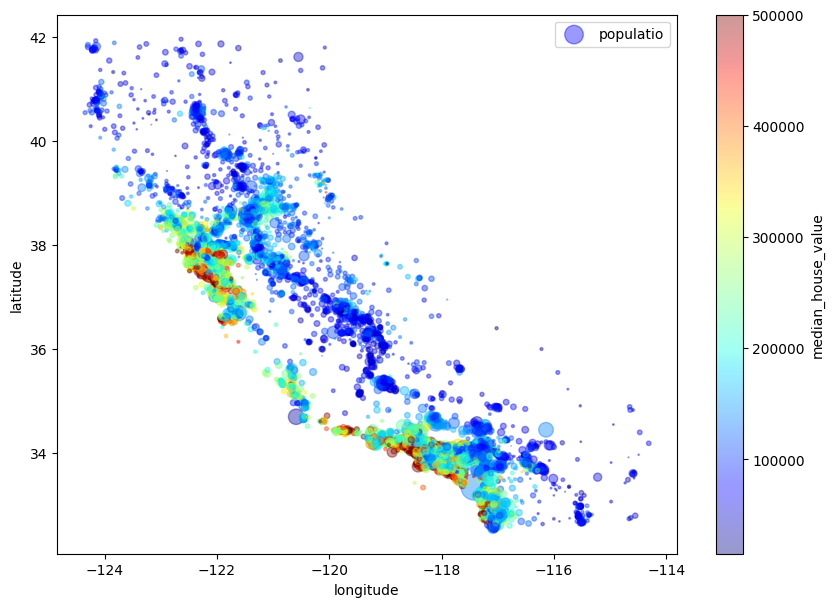

In [48]:
housing.plot(kind="scatter",x="longitude",y="latitude",alpha=0.4,
            s=housing["population"]/100,label="populatio",figsize=(10,7),
            c="median_house_value" , cmap=plt.get_cmap("jet"),colorbar=True,
)
plt.legend()

In [49]:
#LOOKING FOR CORRELATION using the pearson correlation mathematically 

In [50]:
corr_matrix = housing.corr(numeric_only=True)

In [51]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

In [52]:
#FROM THIS WE GOT THE BASIC "LINEAR" RELATION BT THE ATTRIBUTES AND NOW WE DO 2D ANALYSIS USING SCATTER METHOD

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

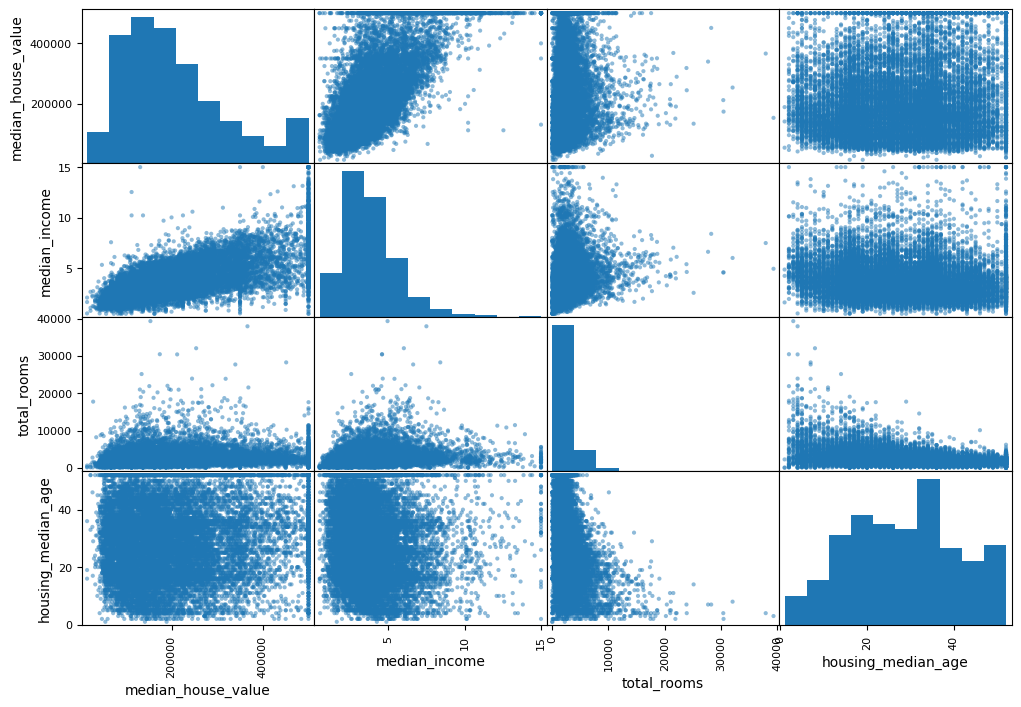

In [53]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value","median_income","total_rooms","housing_median_age"]
scatter_matrix(housing[attributes],figsize = (12,8))

In [54]:
#lets zoom in

<Axes: xlabel='median_income', ylabel='median_house_value'>

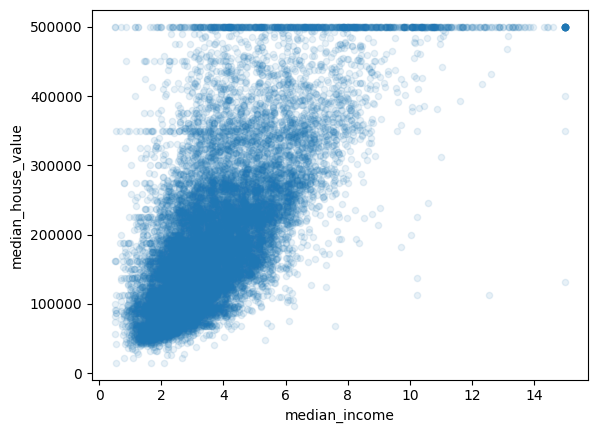

In [55]:
housing.plot(kind="scatter",x="median_income",y="median_house_value" , alpha =0.1)

In [56]:
#CREATING NEW ATTRIBUTES COMBINATION

In [57]:
housing["rooms_per_household"]= housing["total_rooms"]/housing["households"]

In [58]:
housing["bedrooms_per_room"]=housing["total_bedrooms"]/housing["total_rooms"]

In [59]:
housing["population_per_household"]= housing["population"]/housing["households"] 

In [60]:
#LETS RETEST THE CORRELATION MATRIX

In [61]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending = False)

median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64

In [62]:
#PREPARE THE DATA FOR ML ALGO

In [63]:
#A CLEAN COPY OF THE DATA AND ITS LABELS (NOW WE DO IT)
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [64]:
#DATA CLEANING
#simple imputer

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = "median")

#the median can only be computed on numerical attributes, you need to create a
#copy of the data without the text attribute ocean_proximity:

housing_num = housing.drop("ocean_proximity", axis =1 )

#use fit() method 

imputer.fit(housing_num)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['longitude','latitude','housing_median_age',...,'population','households', 'median_income']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](8,)","[-118.51, 34.26, 29. ,...,1164. , 408. , 3.54]"


In [65]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [66]:
housing_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [67]:
#ACTUAL TRANSFORMATION 

X = imputer.transform(housing_num)

In [68]:
#The result is a plain NumPy array containing the transformed features. If you want to
#put it back into a pandas DataFrame, it’s simple:

housing_tr = pd.DataFrame(X, columns = housing_num.columns , index = housing_num.index)

In [69]:
#Handling Text and Categorical Attributes (ocean_proximity attribute)

housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

#we use OrdinalEncoder for converting this categories from text to number 

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


In [70]:
from sklearn.preprocessing import OrdinalEncoder 
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]                    

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [71]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [72]:
#THIS IS BASICALLY GIVING PROBLEM YK 1 CLOSER TO 2 THAN 2 SOO WE USE OneHotEncoder()

In [73]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder =OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [74]:
housing_cat_1hot.toarray()

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(16512, 5))

In [75]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [76]:
##CUSTOM TRANSFORMER
#To make your class act exactly like a built-in Scikit-Learn transformer, 
#it just needs to have three specific methods

##CUSTOM TRANSFORMER
#To make your class act exactly like a built-in Scikit-Learn transformer, it just needs to have three specific methods

from sklearn.base import BaseEstimator, TransformerMixin
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]



        

In [77]:
    attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
    housing_extra_attribs = attr_adder.transform(housing.values)

In [78]:
##FEATURE SCALING 
#TWO COMMON WAYS -- MIN-MAX SCALING(NORMALIZATION) AND STANDARDISATION 
#MIN- MAX(NORMALIZTION) - values are shifted and rescaled such that they end up ranging from 0 to 1
#transformer for normalization is MinMaxScaler has feature_range() hyperparameter if u want to change the range

In [79]:
#STANDARDISATION 
#first it subtracts the mean value and then it divides by the standard deviation so that the
#resulting distribution has unit variance.
#doesn't bind the values to a specific range...
#the plus point here is that standardisation is much less affected by outliers yk 
#the transformer for this is StandardScaler

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [86]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = "median")),
    ('attribs_adder' , CombinedAttributesAdder()),
    ('std_scaler',StandardScaler()),
])

In [87]:
housing_num_tr = num_pipeline.fit_transform(housing_num)

In [ ]:
#The Pipeline constructor takes a list of name/estimator pairs defining a sequence of
#steps. All but the last estimator must be transformers (i.e., they must have a
#fit_transform() method). The names can be anything you like (as long as they are
#unique and don’t contain double underscores, __)
#double scores are for hyperprarameter tuning

In [89]:
#When you call the pipeline’s fit() method, it calls fit_transform() sequentially on
#all transformers, passing the output of each call as the parameter to the next call until
#it reaches the final estimator, for which it calls the fit() method.

In [91]:
#we have handled the categorical columns and the numerical columns separately.
#It would be more convenient to have a single transformer able to handle all columns,
#applying the appropriate transformations to each column

#Scikit-Learn introduced the ColumnTransformer for this purpose, and the good news
#is that it works great with pandas DataFrames

In [93]:
from sklearn.compose import ColumnTransformer

num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num" , num_pipeline , num_attribs),
    ("cat", OneHotEncoder() , cat_attribs),
    
])
housing_prepared = full_pipeline.fit_transform(housing)

In [94]:
#SELECT AND TRAIN A MODEL FINALLYYYY
#LESSSSSSSSGOOOOOOOOOOOOO

In [95]:
#LETS SELECT THE LINEAR REGRESSION MODEL AND TRAIN IT ON OUR DATA WE HAVE DONE ALL THE HARD PART BEFORE SO THIS PART IS MUCH EASIER

In [96]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared , housing_labels)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[-55649.63,-56711.6 , 13734.72,...,110357.85,-22484.66,-14642.49]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.369e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,15
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[254.01,184.89,173.42,..., 15.9 , 1.58, 0. ]"


In [99]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)
print("Predictions:", lin_reg.predict(some_data_prepared))
print("Labels",list(some_labels))

Predictions: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]
Labels [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


In [101]:
#IT LOOKS LIKE THE PREDICTIONA ARE ACTUALLY NOT THAT ACCURATE(e.g., the first prediction is off by close to 40%!)

In [102]:
#Let’s measure this regression model’s RMSE on the whole training
#set using Scikit-Learn’s mean_squared_error() function

In [107]:
from sklearn.metrics import mean_squared_error
hosuing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels , hosuing_predictions)
lin_rmse = np.sqrt(lin_mse)
print(lin_rmse)

68627.87390018745


In [108]:
#This is better than nothing, but clearly not a great score: most districts’ median_hous
#ing_values range between $120,000 and $265,000, so a typical prediction error of
#$68,628 is not very satisfying. This is an example of a model underfitting the training
#data.

In [110]:
#well as we the cures for underfitting the data are use a more complex model , add more feature or just yk remove regularities . WEll this model isn't r
#regularized so that aint an option 
#Let's try a more complex model
#Let’s train a DecisionTreeRegressor. This is a powerful model, capable of finding
#complex nonlinear relationships in the data

In [114]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared , housing_labels)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

In [117]:
from sklearn.metrics import mean_squared_error
housing_prediction = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_prediction , housing_labels)
tree_rmse = np.sqrt(tree_mse)

In [119]:
print(tree_rmse)

0.0


In [120]:
#Wait, what!? No error at all? Could this model really be absolutely perfect? Of course,
#it is much more likely that the model has badly overfit the data.

In [121]:
##Better Evaluation Using Cross-Validation

In [122]:
#A great alternative is to use Scikit-Learn’s K-fold cross-validation feature. The following
#code randomly splits the training set into 10 distinct subsets called folds, then it
#trains and evaluates the Decision Tree model 10 times, picking a different fold for
#evaluation every time and training on the other 9 folds. The result is an array containing
#the 10 evaluation scores:

In [124]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree_reg , housing_prepared , housing_labels , 
                         scoring = "neg_mean_squared_error" , cv = 10 )
tree_rmse_score = np.sqrt(-scores)

In [127]:
def display_scores(scores):
    print ("scores",scores)
    print("Mean",scores.mean())
    print("StandardDeviation", scores.std())

In [131]:
display_scores(tree_rmse_score)

scores [72454.49717953 69697.69687758 67350.30375155 71216.92057495
 69766.13167005 78285.80849558 72312.28810393 73297.10901191
 66885.25691095 71265.9251926 ]
Mean 71253.19377686277
StandardDeviation 3084.540404832625


In [132]:
#notice that cross-validation allows
#you to get not only an estimate of the performance of your model, but also a measure
#of how precise this estimate is

In [133]:
#lets try the cross validation for the linear regression model

In [134]:
lin_scores = cross_val_score(lin_reg, housing_prepared ,housing_labels,
                             scoring = "neg_mean_squared_error" , cv = 10 
                            )
lin_rmse_score = np.sqrt(-lin_scores)
display_scores(lin_rmse_score)

scores [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean 69104.07998247063
StandardDeviation 2880.3282098180584


In [135]:
#the Decision Tree model is overfitting so badly that it performs worse
#than the Linear Regression model.

In [137]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared , housing_labels)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [138]:
from sklearn.metrics import mean_squared_error
hosuing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels , hosuing_predictions)
forest_rmse = np.sqrt(forest_mse)
print(forest_rmse)

18784.559339961957


In [141]:
forest_scores = cross_val_score(lin_reg, housing_prepared ,housing_labels,
                             scoring = "neg_mean_squared_error" , cv = 10 
                            )
forest_rmse_score = np.sqrt(-forest_scores)
display_scores(forest_rmse_score)

scores [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean 69104.07998247063
StandardDeviation 2880.3282098180584


In [142]:
#Random Forests look very promising. However, note that
#the score on the training set is still much lower than on the validation sets, meaning
#that the model is still overfitting the training set

In [143]:
#to eliminate overfitting of model you  can do this - either just get a load more training data or constriant the model 


In [144]:
#Before you dive much deeper into Random Forests, however, you should try out
#many other models from various categories of Machine Learning algorithms (e.g.,
#several Support Vector Machines with different kernels, and possibly a neural network),
#without spending too much time tweaking the hyperparameters. The goal is to
#shortlist a few (two to five) promising models.

In [146]:
#You should save every model you experiment with so that you can
#come back easily to any model you want. Make sure you save both
#the hyperparameters and the trained parameters, as well as the
#cross-validation scores and perhaps the actual predictions as well.
#This will allow you to easily compare scores across model types,
#and compare the types of errors they make. You can easily save
#Scikit-Learn models by using Python’s pickle module or by using
#the joblib library, which is more efficient at serializing large
#NumPy arrays (you can install this library using pip):

In [147]:
#CODE TO SAVE THE RESLUTS OF THE DIFFERENT MODELS AS DESCRIBED EARLIER

In [161]:
#import joblib

# Replace 'my_model' with your actual trained model's variable name (e.g., forest_reg)
#joblib.dump(forest_reg, "my_model.pkl")

# And later when you want to load it back into memory...


In [160]:
#my_model_loaded = joblib.load("my_model.pkl")

In [154]:
#Think of it like saving a chef's brain after they learned a recipe

In [155]:
#well the problem with git is that u cant save the entire model cause it's big and exceeds the 100 mb limit on the git 
#commit and all , to buypas by ", we are going to fix this by saving a tiny text "report card" instead."

In [158]:
#code for creating the "report card text file

import os
import csv
from datetime import datetime

def log_model_score(model_name , rmse_score , notes =""):
    """SAVES YOUR MODEL'S PERFORMANCE to a csv file to track your growth """
    file_name = "experiment_log.csv"
    #CHECK IF THE FILE ALREADY EXISTS SO WE KNOW WE HAVE TO WRITE THE HEADERS 
    file_exists = os.path.isfile(file_name)
    with open(file_name, mode='a', newline='') as file:
        writer = csv.writer(file)
        
        # If the file is brand new, create the column headers first
        if not file_exists:
            writer.writerow(["Date", "Model", "RMSE Score", "Notes"])
            
        # Log the actual data
        current_time = datetime.now().strftime("%Y-%m-%d %H:%M")
        writer.writerow([current_time, model_name, rmse_score, notes])
        
    print(f"✅ Successfully logged {model_name} to {file_name}")

In [159]:
forest_rmse_score =18784.559339961957
# Log it!
log_model_score("forest ", forest_rmse_score, "Default settings, slightly overfitting")

✅ Successfully logged forest  to experiment_log.csv
